# ARIM-Academy：　基礎編　Scikit-learn（次元削減とクラスター分析）

**対象読者：** Python基礎文法を理解している方。`Scikit-learn-5_Classification.ipynb`（分類編）を先に学習していることを前提とします。

**前提知識：** 標準化、train/testの分割は既習として説明を省略します（本編ではラベルを使わないため、分割自体は行いません）。**次元削減**・**クラスタリング**は初出の用語として説明します。

**動作環境：** Python 3.10以降 / pandas 2.x / numpy 1.26以降 / matplotlib 3.8以降 / seaborn 0.12以降 / scikit-learn 1.2以降 / umap-learn。Google Colabでは`umap-learn`のみ追加インストールが必要です（次のセルで自動的にインストールします）。

**版・ライセンス：** 本ノートブックのコード部分はMITライセンスで提供します。

---

## 本編の目標
本演習では**『茶の元素分析データセット』**（分類編と同じデータ）を用いて、**教師なし学習（Unsupervised Learning）**に分類される**次元削減**と**クラスタリング**の技術を学びます。

> **教師あり学習との違い：** 前編（`Scikit-learn-5_Classification.ipynb`）で扱った決定木・ランダムフォレスト・SVMは、茶葉の品種ラベルを使って学習する教師あり学習でした。本編で扱うPCA・t-SNE・UMAP（次元削減）や階層クラスタリング・k-means（クラスタリング）は、**ラベルを一切使わずに**データの構造を見つけ出す教師なし学習です。可視化の際に品種ラベルで色分けしますが、これはあくまで「教師なしの手法がどれだけ品種の違いを反映した構造を見つけられたか」を人間が確認するためであり、モデル自体はラベルを使っていません。

### 本編における内容
1. **次元削減技術の学習**: 高次元データを低次元に変換する次元削減手法（主成分分析（PCA）、t-SNE、UMAP）を学びます。
2. **クラスタリングアルゴリズムの理解**: クラスタリング手法（階層クラスタリングやK-means）を使用して、データセット内の類似性、グループやパターンを識別します。
3. **次元削減とクラスタリングの統合的活用**: 次元削減によって得られた低次元のデータを用いて、クラスタリング結果を視覚化します。

---

## データセット
分類編と同じ**『茶の元素分析データセット』**（4品種×42件＝168件、9元素）を使用します。データセットの詳細は`Scikit-learn-5_Classification.ipynb`を参照してください。

### 教材への接続
Google Colab環境でこのノートブックを実行する場合は、次のセルを実行してください。（<font color="red">ローカル環境などGoogle Colabを使わない場合は不要です</font>）

In [ ]:
%pip install umap-learn

!git clone https://github.com/ARIM-Academy/Advanced_Tutorial_1.git
%cd Advanced_Tutorial_1

# 1. データセットの読み込みと前処理

### ライブラリのインポート
カリキュラムで扱うpythonのライブラリを`import`文でロードします。機械学習のライブラリであるscikit-learnは後半でimportします。

In [1]:
#ライブラリ
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import matplotlib_fontja
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

### サンプルファイルの読み込み
pandasライブラリの`read_csv()`はcsvファイルを読み込むメソッドであり、指定したファイルを読み込みます。ここでは[data]フォルダーに格納されている`tea_data.csv`のファイルをデータフレームとして読み込み、そのデータフレームは`df`という変数に格納します。

In [2]:
#データセットの読み込み
df=pd.read_csv("data/tea_data.csv")
df

,Al,Ca,Cu,Fe,K,Mg,Mn,Na,Zn,tea
0,3.297,4.356,0.031290,0.067,99.06,3.531,1.455,0.541,0.131,BT
1,4.267,4.118,0.031290,0.079,106.50,3.378,1.542,0.603,0.126,BT
2,4.088,4.763,0.033370,0.084,114.00,4.763,1.838,1.058,0.156,BT
3,4.338,4.556,0.033370,0.091,122.60,5.005,2.269,0.958,0.162,BT
4,4.732,5.138,0.035514,0.110,132.40,5.626,2.998,1.510,0.165,BT
...,...,...,...,...,...,...,...,...,...,...
163,16.690,8.895,0.153000,0.236,323.40,20.450,10.420,6.360,0.335,GC
164,17.620,8.909,0.177000,0.261,334.20,23.486,11.330,7.133,0.351,GC
165,17.920,9.056,0.180000,0.266,332.30,22.840,11.290,7.609,0.358,GC
166,17.820,9.128,0.175000,0.273,367.30,24.560,12.110,8.537,0.372,GC


### データセットの分割（数値データ部とラベル部）
教師なし学習では訓練/テストへの分割は行いませんが、9つの数値データ（説明変数）とラベル（茶の品種）は分けて扱います。ラベル`y`は、次元削減やクラスタリングの計算そのものには使わず、**結果を可視化する際に色分けするためだけ**に使います。

In [3]:
# 数値データ部とラベル部の用意をしましょう
X = df.drop('tea', axis=1)  # 元素分析データ（Al, Ca, Cu, Fe, K, Mg, Mn, Na, Zn）
y = df['tea']                # 茶の品種（ラベル、可視化の色分けにのみ使用）

In [4]:
X

,Al,Ca,Cu,Fe,K,Mg,Mn,Na,Zn
0,3.297,4.356,0.031290,0.067,99.06,3.531,1.455,0.541,0.131
1,4.267,4.118,0.031290,0.079,106.50,3.378,1.542,0.603,0.126
2,4.088,4.763,0.033370,0.084,114.00,4.763,1.838,1.058,0.156
3,4.338,4.556,0.033370,0.091,122.60,5.005,2.269,0.958,0.162
4,4.732,5.138,0.035514,0.110,132.40,5.626,2.998,1.510,0.165
...,...,...,...,...,...,...,...,...,...
163,16.690,8.895,0.153000,0.236,323.40,20.450,10.420,6.360,0.335
164,17.620,8.909,0.177000,0.261,334.20,23.486,11.330,7.133,0.351
165,17.920,9.056,0.180000,0.266,332.30,22.840,11.290,7.609,0.358
166,17.820,9.128,0.175000,0.273,367.30,24.560,12.110,8.537,0.372


In [5]:
y

0      BT
1      BT
2      BT
3      BT
4      BT
       ..
163    GC
164    GC
165    GC
166    GC
167    GC
Name: tea, Length: 168, dtype: str

# 2. 次元削減
**次元削減**は、教師なし学習の一種としてデータ分析や機械学習において重要な手法で、データの持つ特徴量の数を削減し、データの本質的な構造や情報を維持しつつ、データの理解や視覚化を容易にする技術です。  

### 次元削減の種類
ここでは、線形次元削減である主成分分析（PCA）および非線形次元削減（多様体学習法）のt-分布型確率的近傍埋め込み（t-SNE）と統一マニホールド近似と射影（UMAP）について説明します。

1. **PCA(主成分分析)** :  
   PCAは線形次元削減手法であり、データの分散を最大化する直交する軸（主成分）を見つけます。PCAはデータの分布の最も重要な方向を特定し、特徴量間の関連性を明らかにします。PCAはデータの線形な関係性を捉えるのに適しています。

2. **t-SNE（t-分布型確率的近傍埋め込み）**:  
    t-SNEは、非線形次元削減手法であり、特にデータのクラスタリング構造を視覚化するのに優れています。t-SNEは高次元データの局所的な構造を低次元空間に保持し、データポイント間の類似性を視覚的に表現します。

3. **UMAP（統一マニホールド近似と射影）**:  
    UMAPは、t-SNEと同様に非線形次元削減手法で、データの局所的および大域的な構造を保持しつつ、次元を削減します。UMAPは計算が速く、大規模データセットにも適用可能です。

## 1. 主成分分析
次元削減の一番汎用的な手法である「主成分分析」を行ってみましょう。

### ①　モデル構築
PCAクラスは、Scikit-learnライブラリから提供される主成分分析のクラスです。主成分分析では、データの次元を削減し、データの最も重要な変動を捉えるモデルを構築します。

まずは、標準化を**行わずに**そのままのデータでPCAを実行してみます（この後、標準化した場合と比べます）。

In [35]:
from sklearn.decomposition import PCA

In [7]:
# 主成分分析（PCA）で2次元に次元削減（標準化なし）
pca = PCA(n_components=2)  # 2次元に次元削減
X_pca = pca.fit_transform(X)

### 【解説】PCAのハイパーパラメータ
主成分分析（PCA）は、データの次元を削減するための手法であり、データの分散を最大化する直交する軸（主成分）を見つけます。PCAには少数のハイパーパラメータがあり、それらを適切に設定することで次元削減の結果を調整できます。以下はPCAの主なハイパーパラメータです。

1. **`n_components`**
- **説明**: 保持する主成分の数を指定します。これにより、次元削減後のデータセットの次元数が決定されます。
  - **整数値**: 保持する主成分の数を指定。例えば、`n_components=2`なら、2次元に削減されます。
  - **0 < n_components < 1 の小数値**: 累積寄与率が指定された値に達するまで主成分を保持。例えば、`n_components=0.95`なら、データの95%の分散を説明するのに十分な数の主成分が保持されます。
  - **`None`**: すべての成分が保持されますが、次元削減は行われません。
- **デフォルト値**: `None`

2. **`svd_solver`**
- **説明**: 特異値分解（SVD）を行うためのアルゴリズムを指定します。データのサイズや特性に応じて適切なアルゴリズムを選択します。
  - **`auto`**: デフォルトで、データセットのサイズに基づいて最適なアルゴリズムを選択します。
  - **`full`**: 完全なSVDを計算します。データが少ない場合や精度が求められる場合に使用します。
  - **`randomized`**: ランダム化されたSVDを計算します。高速で、大規模データに適しています。

3. **`whiten`**
- **説明**: `True`に設定すると、主成分が分散1になるようにスケーリングされます。
- **デフォルト値**: `False`

4. **`random_state`**
- **説明**: `svd_solver='randomized'`の場合に使用される乱数シード。再現性のために設定します。
- **デフォルト値**: `None`

### その他の考慮事項
- **データの標準化**: PCAを実行する前にデータを標準化することが一般的です。これは、各特徴量のスケールが異なる場合に、主成分の抽出がそのスケールの影響を受けるのを防ぐためです。次のセクションで、標準化の有無による結果の違いを実際に確認します。

### ②　二次元プロット（可視化）

次元削減の結果を視覚化するためのグラフです。主成分分析では**スコアプロット**とも呼ばれ、データのクラスタリングやクラス間の分離状態を確認でき、PCAによって次元削減がどれだけ有効であったかを直感的に理解することができます。

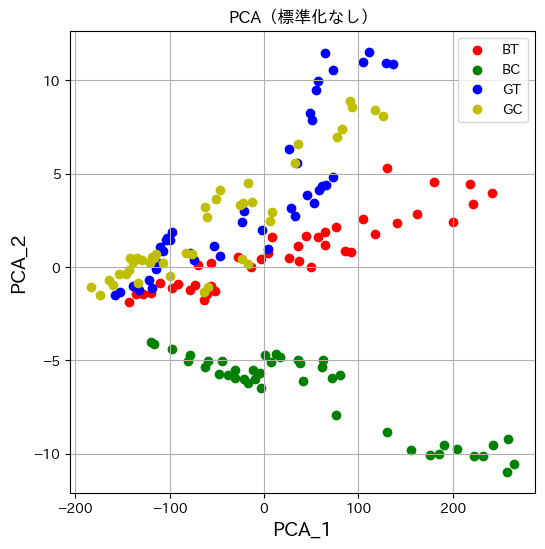

In [8]:
# PCAのプロット（標準化なし）
plt.figure(figsize=(6, 6))

colors = ['r', 'g', 'b','y']
species = ['BT', 'BC', 'GT','GC']

for color, specie in zip(colors, species):
    plt.scatter(X_pca[y == specie, 0], X_pca[y == specie, 1], 
                label=specie, 
                color=color
               )

plt.xlabel('PCA_1', fontsize =14)
plt.ylabel('PCA_2', fontsize =14)

plt.legend()
plt.grid()
plt.title('PCA（標準化なし）')
plt.show()

In [9]:
# 標準化なしの場合、PC1だけでどれだけの分散を説明しているか、
# また、どの元素がPC1を支配しているかを確認してみましょう
print('寄与率（標準化なし）:', np.round(pca.explained_variance_ratio_, 3))
print()
print('PC1の各元素の重み（絶対値が大きいほど影響大）:')
print(pd.Series(pca.components_[0], index=X.columns).sort_values())

寄与率（標準化なし）: [0.997 0.002]

PC1の各元素の重み（絶対値が大きいほど影響大）:
Cu    0.000105
Fe    0.000231
Zn    0.000738
Ca    0.005871
Na    0.009524
Mn    0.019012
Al    0.029193
Mg    0.068693
K     0.996966
dtype: float64


結果を見ると、**PC1だけでほぼ100%の分散を説明**しており、しかもPC1の重みはほぼ`K`（カリウム）だけで決まっていることが分かります。これは「PCAが本当に9元素すべての情報をバランスよく統合した」のではなく、**単に一番数値の大きい`K`（濃度が他の元素より2桁近く大きい）にPCAが引きずられているだけ**であることを意味します。次に、標準化してから同じことをやり直してみましょう。

### ③　標準化
PCAは、データのスケールに敏感であるため、次元削減の前に標準化が必要です。標準化では、各特徴量を平均0、標準偏差1にスケーリングし、異なるスケールを持つ特徴量が等しく扱われるようにします。これにより、PCAが特徴量のスケールに依存せず、データ全体の構造を正確に反映できます。

In [10]:
from sklearn.preprocessing import StandardScaler

In [11]:
# データの標準化
scaler = StandardScaler()
X_std = scaler.fit_transform(X)

In [12]:
# 主成分分析（PCA）：後の寄与率の確認のため、9つの主成分すべてを計算する
pca = PCA(n_components=9)  
X_pca = pca.fit_transform(X_std)

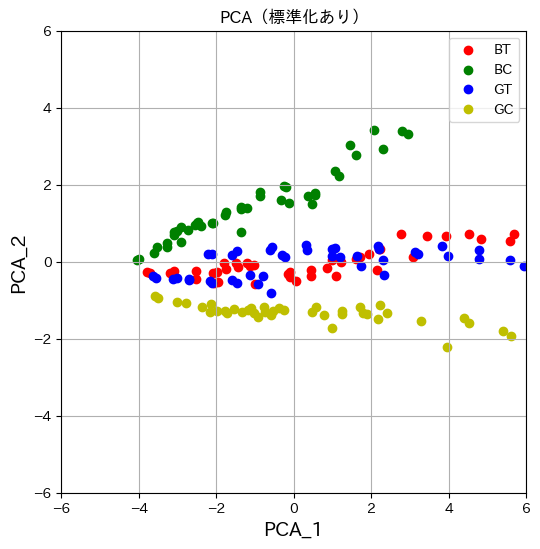

In [13]:
# PCAのプロット（標準化あり、PC1・PC2のみ表示）
plt.figure(figsize=(6, 6))

colors = ['r', 'g', 'b','y']
species = ['BT', 'BC', 'GT','GC']

for color, specie in zip(colors, species):
    plt.scatter(X_pca[y == specie, 0], X_pca[y == specie, 1], 
                label=specie, 
                color=color
               )

plt.xlabel('PCA_1', fontsize =14)
plt.ylabel('PCA_2', fontsize =14)
plt.xlim(-6,6)
plt.ylim(-6, 6)

plt.legend()
plt.grid()
plt.title('PCA（標準化あり）')
plt.show()

### 標準化の効果を数値で確認する
標準化した場合の寄与率を見てみましょう。標準化前は「PC1だけでほぼ100%」でしたが、標準化後はどう変わるでしょうか。

In [14]:
print('寄与率（標準化あり）:', np.round(pca.explained_variance_ratio_, 3))
print('PC1が説明する分散の割合:', round(pca.explained_variance_ratio_[0]*100, 1), '%（標準化前は99.7%でした）')

寄与率（標準化あり）: [0.717 0.14  0.077 0.029 0.021 0.007 0.006 0.002 0.002]
PC1が説明する分散の割合: 71.7 %（標準化前は99.7%でした）


標準化後は、PC1が説明する分散の割合が大きく下がり、PC2以降も意味のある情報を持つようになったことが分かります。標準化前のPCAは実質的に「Kの量だけを見ている」に等しく、品種間の分離もはっきりしませんが、標準化後のグラフでは4品種がある程度分かれて分布している様子が見えるはずです。**PCAを使うときは、原則として標準化してから行うべき**であることが、この比較から実感できます。

### ④　寄与率と累積寄与率
PCAでは、データセットの特徴量を直交する新たな軸（主成分）に変換しますが、それぞれの主成分は、元のデータの分散（情報量）をどの程度説明できるかを示す寄与率を持ちます。例えば、寄与率が0.4であれば、その主成分だけで元のデータの40%の分散を説明できることを意味します。累積寄与率は、最初のn個の主成分まででどれだけの分散を説明できるかを示します。累積寄与率が1に近づくほど、それまでの主成分がほぼ全ての分散を説明していることを意味します。

pythonでは`explained_variance_ratio_`からは各主成分の寄与率を計算できます。`np.cumsum()`メソッドより累積寄与率を計算します。

In [15]:
# 寄与率の計算
explained_variance_ratio = pca.explained_variance_ratio_

# 累積寄与率の計算
cumulative_explained_variance = np.cumsum(explained_variance_ratio)

In [16]:
explained_variance_ratio

array([0.71650408, 0.13997561, 0.07671744, 0.02861021, 0.02109378,
       0.00737171, 0.00557342, 0.00230621, 0.00184754])

In [17]:
cumulative_explained_variance

array([0.71650408, 0.85647969, 0.93319713, 0.96180734, 0.98290112,
       0.99027283, 0.99584625, 0.99815246, 1.        ])

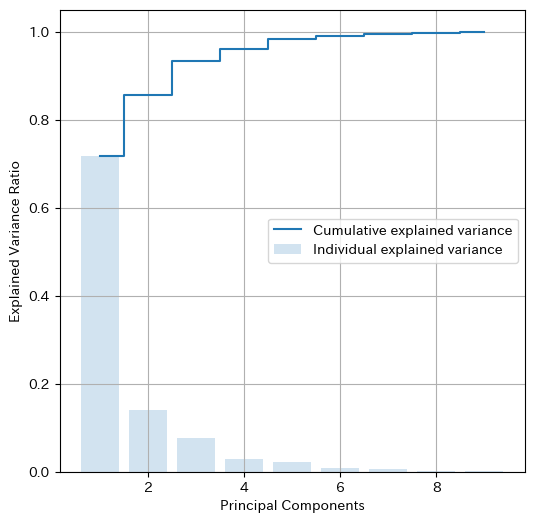

In [18]:
# 寄与率のプロット
plt.figure(figsize=(6, 6))

plt.bar(range(1, 10), explained_variance_ratio, alpha=0.2, align='center',
        label='Individual explained variance')

plt.step(range(1, 10), cumulative_explained_variance, where='mid',
         label='Cumulative explained variance')

plt.xlabel('Principal Components')
plt.ylabel('Explained Variance Ratio')

plt.legend()
plt.grid()
plt.show()

## 2. t-分布型確率的近傍埋め込み（t-SNE）
t-分布型確率的近傍埋め込み（t-SNE）は、高次元データを低次元空間に効果的に埋め込む手法です。この手法は、データポイント間の局所的な類似性を保持しながら、データの高次元構造を視覚化します。

In [19]:
from sklearn.manifold import TSNE

### ①　モデル構築
t-SNEクラスは、Scikit-learnライブラリから提供されるt-分布型確率的近傍埋め込みのクラスです。このクラスを使用して、高次元データを低次元空間に埋め込み、データの局所的な構造を保持しながら視覚化します。t-SNEは、データポイント間の類似性を反映する2次元または3次元のプロットを生成し、複雑なデータのパターンを理解するのに役立ちます。

In [20]:
# t-SNEの実行（標準化なし）
tsne = TSNE(n_components=2, random_state=42)
X_tsne = tsne.fit_transform(X)

### 【解説】t-SNEの主なハイパーパラメータ

| パラメータ | 説明 | デフォルト値 |
| --- | --- | --- |
| `n_components` | 埋め込み後の次元数。通常2または3。 | 2 |
| `perplexity` | 近傍とみなす点の数の目安。小さいと局所的構造、大きいと大域的構造を重視。データ数に応じて5〜50程度で調整。 | 30 |
| `learning_rate` | 埋め込み空間での更新のステップサイズ。小さすぎると収束が遅く、大きすぎると発散する可能性がある。 | 200（自動調整の場合あり） |
| `n_iter` | 最適化の反復回数。通常1000回以上が推奨される。 | 1000 |
| `init` | 埋め込みの初期化方法。`'random'`または`'pca'`。 | `'pca'`（新しいバージョンでは`'pca'`が既定になっています） |
| `metric` | データ間の距離指標。ユークリッド距離（`'euclidean'`）など。 | `'euclidean'` |
| `random_state` | 再現性のための乱数シード。 | `None` |

特に`perplexity`と`learning_rate`は結果の見た目に大きく影響するため、いくつかの値を試して比較することが推奨されます。

### ②　二次元プロット（可視化）

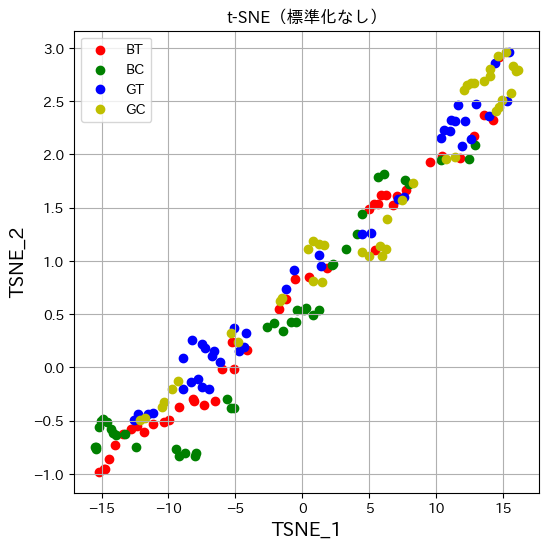

In [21]:
# t-SNEのプロット（標準化なし）
plt.figure(figsize=(6, 6))

colors = ['r', 'g', 'b','y']
species = ['BT', 'BC', 'GT','GC']

for color, specie in zip(colors, species):
    plt.scatter(X_tsne[y == specie, 0], X_tsne[y == specie, 1], 
                label=specie, 
                color=color
               )

plt.xlabel('TSNE_1', fontsize =14)
plt.ylabel('TSNE_2', fontsize =14)

plt.legend()
plt.grid()
plt.title('t-SNE（標準化なし）')
plt.show()

### ③　標準化

t-分布型確率的近傍埋め込み（t-SNE）を適用する際には、データの標準化が推奨されます。標準化を進めることで、データのスケールによる偏りを防ぎ、より正確で意味のある可視化を得ることができます。標準化を行わないと、データのスケールによってt-SNEの結果が歪む可能性があります。その影響を、PCAのときと同様に比較してみましょう。

In [22]:
X_tsne_std = tsne.fit_transform(X_std)

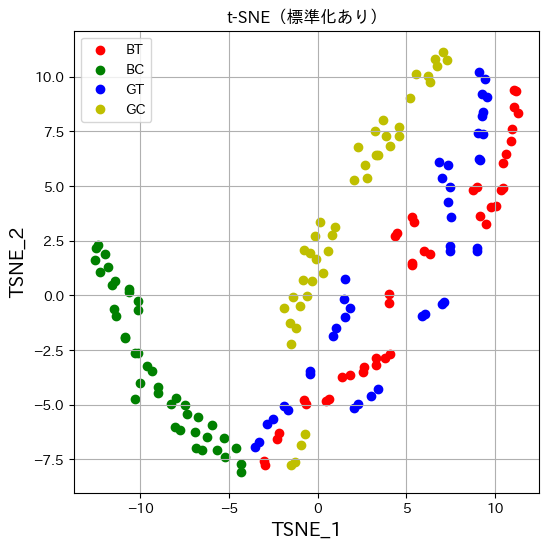

In [23]:
# t-SNEのプロット（標準化あり）
plt.figure(figsize=(6, 6))

colors = ['r', 'g', 'b','y']
species = ['BT', 'BC', 'GT','GC']

for color, specie in zip(colors, species):
    plt.scatter(X_tsne_std[y == specie, 0], X_tsne_std[y == specie, 1], 
                label=specie, 
                color=color
               )

plt.xlabel('TSNE_1', fontsize =14)
plt.ylabel('TSNE_2', fontsize =14)

plt.legend()
plt.grid()
plt.title('t-SNE（標準化あり）')
plt.show()

PCAほど劇的な違いではありませんが、標準化の有無でクラスタの見え方（品種ごとの固まりの分離具合）が変わることを確認してください。t-SNEは距離をベースにした手法のため、PCAと同様にスケールの影響を受けます。

## 3. 統一マニホールド近似と射影（UMAP）
統一マニホールド近似と射影（UMAP）は、高次元データを低次元空間に効率的に埋め込む手法です。UMAPは、データの局所的な構造と全体的な構造を保持しながら、複雑なデータの可視化を行います。

In [24]:
import umap

### ①　モデル構築
UMAPクラスは、umap-learnライブラリから提供される統一マニホールド近似と射影の実装クラスです。このクラスを使用して、高次元データを低次元空間に効果的に埋め込むことができます。

In [25]:
# UMAPの実行（標準化なし）
umap_model = umap.UMAP(n_components=2, random_state=42)
X_umap = umap_model.fit_transform(X)

### 【解説】UMAPの主なハイパーパラメータ

| パラメータ | 説明 | デフォルト値 |
| --- | --- | --- |
| `n_neighbors` | 近傍点の数。小さいと局所構造、大きいと大域構造を強調。5〜50程度が目安。 | 15 |
| `min_dist` | 埋め込み空間での点同士の最小距離。小さいと密集、大きいと疎になる。 | 0.1 |
| `n_components` | 埋め込み後の次元数。 | 2 |
| `metric` | 距離指標（`'euclidean'`など）。 | `'euclidean'` |
| `random_state` | 再現性のための乱数シード。 | `None` |

`n_neighbors`と`min_dist`は結果への影響が大きいため、特に注目すべきパラメータです。

### ②　二次元プロット（可視化）

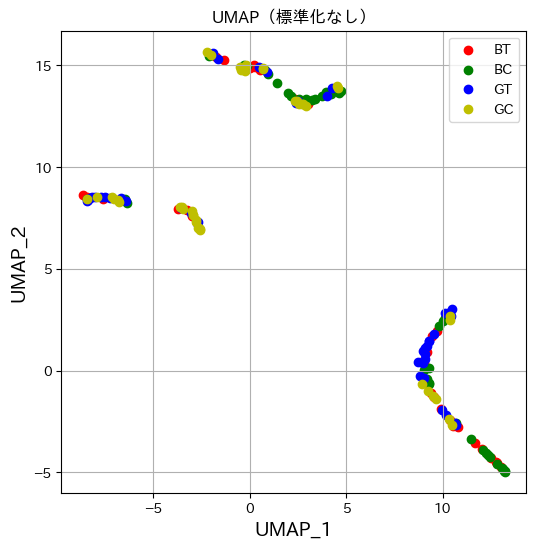

In [26]:
# UMAPのプロット（標準化なし）
plt.figure(figsize=(6, 6))

colors = ['r', 'g', 'b','y']
species = ['BT', 'BC', 'GT','GC']

for color, specie in zip(colors, species):
    plt.scatter(X_umap[y == specie, 0], X_umap[y == specie, 1], 
                label=specie, 
                color=color
               )

plt.xlabel('UMAP_1', fontsize =14)
plt.ylabel('UMAP_2', fontsize =14)

plt.legend()
plt.grid()
plt.title('UMAP（標準化なし）')
plt.show()

### ③　標準化

UMAPについても、PCA・t-SNEと同様に標準化が推奨されます。ここでも標準化を通じた影響について比較してみましょう。

In [27]:
X_umap_std = umap_model.fit_transform(X_std)

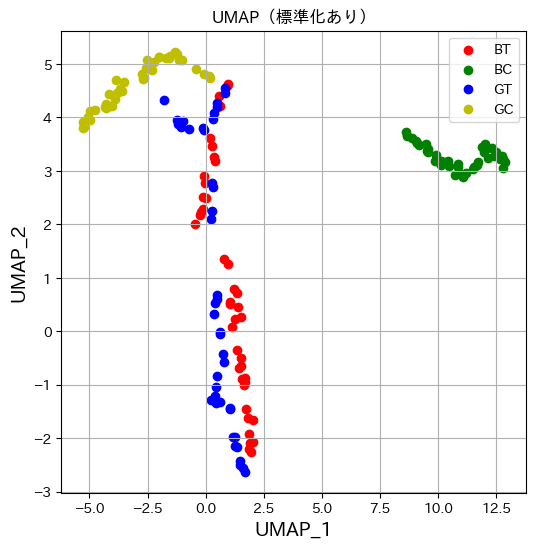

In [28]:
# UMAPのプロット（標準化あり）
plt.figure(figsize=(6, 6))

colors = ['r', 'g', 'b','y']
species = ['BT', 'BC', 'GT','GC']

for color, specie in zip(colors, species):
    plt.scatter(X_umap_std[y == specie, 0], X_umap_std[y == specie, 1], 
                label=specie, 
                color=color
               )

plt.xlabel('UMAP_1', fontsize =14)
plt.ylabel('UMAP_2', fontsize =14)

plt.legend()
plt.grid()
plt.title('UMAP（標準化あり）')
plt.show()

# 3. クラスタリング
**クラスタリング**とは、データをいくつかのグループ（クラスター）に分けるデータ分析手法の一つです。この手法では、同じクラスターに属するデータポイントが互いに類似しており、異なるクラスターのデータポイントとの間には顕著な違いがあるようにします。クラスタリングは、教師なし学習の一種で、事前にラベルが付けられていないデータのパターンを識別するために使用されます。

### クラスタリングの特徴
クラスタリングにはさまざまな方法があり、データの特性や目的に応じて適切なアルゴリズムが選択されます。主なクラスタリング手法には以下があります。

1. **階層クラスタリング**：  
    データポイントを階層的にグループ化する方法です。凝集型（アグロメレイティブ）クラスタリングと分割型（ディバイシブ）クラスタリングに分かれます。結果はデンドログラムとして視覚化され、クラスターの形成過程を視覚的に確認できます。

2. **K-平均法 (K-means）**:  
   事前に設定したクラスター数`k`にデータを分ける方法です。アルゴリズムは、各データポイントを最も近いクラスターの重心に割り当て、クラスターの中心（重心）が最適化されるまで繰り返します。

## 1.階層クラスタリング分析
階層クラスタリングは、データを階層的にグループ化するためのクラスタリング手法です。階層クラスタリングの結果は、デンドログラムと呼ばれるツリーストラクチャーで視覚化されます。デンドログラムでは、クラスターがどのようにして結合されたのか（または分割されたのか）、またクラスター間の距離がどれくらいかが示されます。

> **標準化について：** 後述の「その他の考慮事項」で述べる通り、距離ベースのクラスタリングでは標準化が推奨されます。本データセットは元素ごとの濃度スケールが大きく異なるため（例：Kは100前後、Cuは0.1未満）、ここでは最初から標準化したデータ`X_std`を使います。

In [29]:
from scipy.cluster.hierarchy import linkage, dendrogram

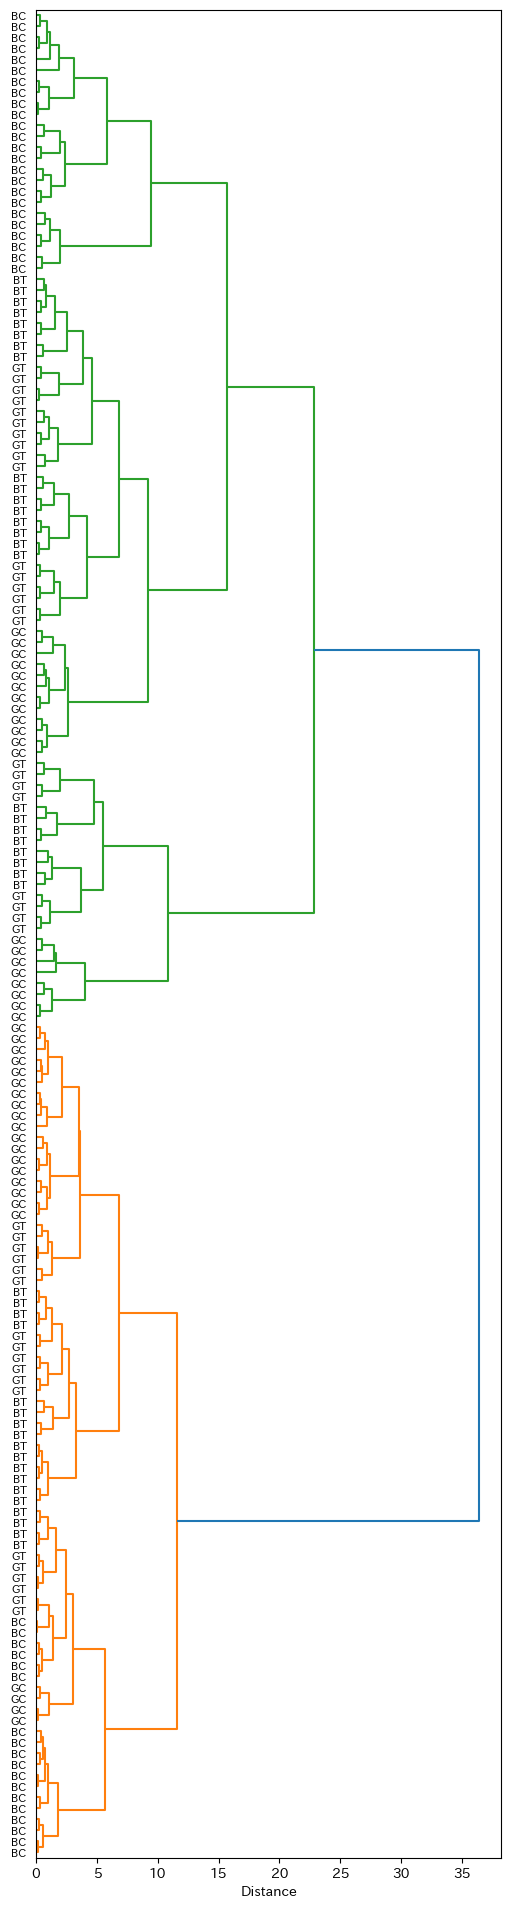

In [30]:
plt.figure(figsize=(6, 24))

# 階層クラスタリング（標準化済みデータを使用）
linkage_matrix = linkage(X_std, method='ward')

dendrogram(linkage_matrix, 
           labels = y.tolist(), 
           orientation = 'right',
          )

plt.xlabel('Distance')
plt.yticks(fontsize=8)  # 品種のフォントサイズを8に設定
plt.show()

### 【解説】階層クラスタリングのハイパーパラメータ
階層クラスタリングは、データの階層的な構造を表現するクラスタリング手法で、クラスタの数を事前に指定する必要がありません。階層クラスタリングの主なハイパーパラメータは、以下のようにクラスタリングの手法とクラスタ間の距離をどのように定義するかに関するものです。

1. **`method`（linkage法）**
- **説明**: クラスタ間の距離をどのように計算するかを指定します。以下のような様々な手法があります:
  - **`single`**: シングルリンク法。最も近いポイント間の距離をクラスタ間の距離とする。
  - **`complete`**: コンプリートリンク法。最も遠いポイント間の距離をクラスタ間の距離とする。
  - **`average`**: 平均リンク法。すべてのペアの平均距離をクラスタ間の距離とする。
  - **`ward`**: ウォード法。全体の分散が最小になるようにクラスタを結合します。デフォルトではこの手法がよく用いられます。

2. **`metric`（距離メトリック）**
- **説明**: データポイント間の距離を計算するためのメトリックを指定します。以下のようなオプションがあります:
  - **`euclidean`**: ユークリッド距離。最も一般的に使用される距離メトリック。
  - **`manhattan`**: マンハッタン距離。各軸に沿った距離の合計。
  - **`cosine`**: コサイン距離。ベクトル間の角度に基づく距離。

3. **`criterion`（停止基準）**
- **説明**: クラスタリングを終了する条件を指定します。一般的なものには以下があります:
  - **`distance`**: 距離のしきい値を指定してクラスタの結合を停止する。
  - **`maxclust`**: 指定されたクラスタ数に達するまでクラスタの結合を続ける。

### その他の考慮事項
- **データの標準化**: 距離ベースのクラスタリング手法では、各特徴のスケールの違いが影響を与えるため、特徴量の標準化やスケーリングが推奨されます。

これらのハイパーパラメータを調整することで、クラスタリングの結果やデンドログラムの解釈が大きく変わります。特に`method`と`metric`の選択は、クラスタリングの特性やデータの構造に大きな影響を与えるため、データの特性に応じて適切に選択することが重要です。

## 2. k-平均法（k-means）
K-平均法の目的は、データセット内のオブジェクトを指定された数（K）のクラスタに分割することです。クラスタは、データの中心点（平均）に基づいて形成されます。このアルゴリズムは以下の手順で実行されます。

まず、K個のクラスタ中心（セントロイド）をランダムに選定します。次に、各データポイントを最も近いクラスタ中心に割り当てます。この際、ユークリッド距離などの距離指標に基づいて、データポイントは最も近いクラスタ中心に属します。その後、各クラスタに属するデータポイントの平均を計算し、新しいクラスタ中心として設定します。このプロセスを、クラスタ中心がほとんど変化しなくなるか、変更が指定された閾値以下になるまで繰り返します。

In [31]:
from sklearn.cluster import KMeans

### ①　モデル構築
KMeansクラスは、scikit-learnライブラリから提供されるクラスタリングアルゴリズムの実装クラスです。このクラスを使用して、データを指定した数のクラスタに分割することができます。標準化済みの`X_std`をそのまま使います。

In [32]:
# WCSSを格納するリスト
wcss = []

# クラスタ数を1から10まで試す
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42, n_init=10)
    kmeans.fit(X_std)
    wcss.append(kmeans.inertia_)

### 【解説】k-平均法のハイパーパラメータ
K-平均法（K-means）は、データをK個のクラスタに分けるクラスタリング手法です。この手法にはいくつかの重要なハイパーパラメータがあり、これらを適切に設定することでクラスタリング結果の品質を改善できます。以下はK-meansの主なハイパーパラメータです。

1. **`n_clusters`**
- **説明**: クラスタの数を指定します。このパラメータはK-meansの最も重要な設定であり、通常はデータセットの性質に応じて最適なクラスタ数を選択します。エルボー法やシルエット分析などの方法を用いて適切なクラスタ数を決定するのが一般的です。
- **デフォルト値**: 8

2. **`init`**
- **説明**: 初期クラスタ中心（セントロイド）の選択方法を指定します。
  - **`k-means++`**: セントロイドを効果的に初期化するためのヒューリスティックな方法。一般的に推奨される方法です。
  - **`random`**: ランダムに初期セントロイドを選ぶ方法。
- **デフォルト値**: `'k-means++'`

3. **`n_init`**
- **説明**: 異なる初期クラスタ中心に対してK-meansアルゴリズムを繰り返す回数。最も低いSSE（Sum of Squared Errors）を持つ結果が選ばれます。これにより、ローカルミニマに陥るリスクを低減します。
- **デフォルト値**: `'auto'`（バージョンにより異なる。明示的に`10`などの整数を指定することも推奨されます）

4. **`max_iter`**
- **説明**: K-meansアルゴリズムの最大反復回数を指定します。
- **デフォルト値**: 300

5. **`random_state`**
- **説明**: 再現性を確保するための乱数シードを指定します。
- **デフォルト値**: `None`

これらのハイパーパラメータの適切な設定は、クラスタリングの品質や効率に大きな影響を与えます。特に、`n_clusters`の選択はクラスタリング結果に直結するため、慎重に選択する必要があります。

### ②　エルボー法の可視化図

#### クラスタ―数の選定
K-meansクラスタリングは、与えられたデータを指定された数のクラスタに分割する手法です。エルボー法（Elbow Method）は、K-meansクラスタリングにおいて適切なクラスタ数を選択するための一般的なアプローチの一つです。

エルボー法のアイデアは、異なるクラスタ数を試して、クラスタ内のばらつき（クラスタ内誤差平方和；SSE：Sum of Squared Error）がどれだけ小さくなるかを評価することです。クラスタ内の誤差平方和は、各データ点とそのクラスタの重心との距離の二乗の合計を示します。これより、誤差平方和が小さい値ほど各データ点がそのクラスタの中に集まっていることを示します。

エルボー法の手順：

1. 異なるクラスタ数（Kの値）を試して、それぞれのクラスタリング結果のクラスタ内誤差平方和を計算。
2. 各クラスタ数に対するクラスタ内誤差平方和（SSE）をプロット。
3. プロットを見て、誤差平方和（SSE）の減少率が急速で減少が鈍化するタイミング（肘部分）を探索。
4. エルボー（肘部分）が見つかったクラスタ数を選択。

この肘部分は、クラスタ数が増加するにつれて、誤差平方和（SSE）の減少率が緩やかになるため、最適なクラスタ数を示すことがあります。  
エルボー法は、クラスタ数を選択するためのヒューリスティックな手法ですが、必ずしも肘部分が明確に見えるわけではなく、実際のデータによっては明らかな肘部分がない場合もあります。そのため、エルボー法を用いつつも、他の方法やドメイン知識と組み合わせて最適なクラスタ数を選択することが重要です。

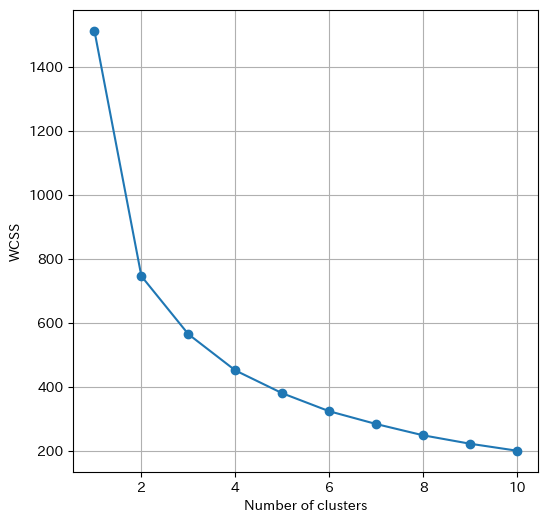

In [33]:
# エルボー法のグラフをプロット
plt.figure(figsize=(6, 6))

plt.plot(range(1, 11), wcss, marker='o')

plt.xlabel('Number of clusters')
plt.ylabel('WCSS')

plt.grid()
plt.show()

> 本データセットには4つの品種（BC・BT・GC・GT）という「正解」がありますが、エルボー法はラベルを一切見ずに、数値データの構造だけから適切なクラスタ数を推定しようとします。グラフの肘の位置が4付近にあるかどうかに注目してみましょう。

### ③　主成分分析（PCA）との併用

PCAは高次元データを低次元に変換する手法であり、データセットの主要な変動を説明する軸（主成分）を見つけます。ここでは、茶の元素分析データセットの9次元のデータ`X`（標準化済み）をPCAで2次元に次元削減し、その図に対してk-meansクラスタリングを適用します。次元削減の大きな利点は、データを2次元または3次元に投影することで、データの構造やクラスタリングの結果を視覚的に確認できる点です。特にK-meansクラスタリングの結果を視覚化する際に、各クラスタがどのように分布しているかを直感的に理解する助けになります。

In [34]:
# K-meansクラスタリング（4クラスタ）
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
y_kmeans = kmeans.fit_predict(X_std)

In [35]:
from sklearn.decomposition import PCA

In [36]:
# 主成分分析（PCA）で2次元に次元削減
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_std)

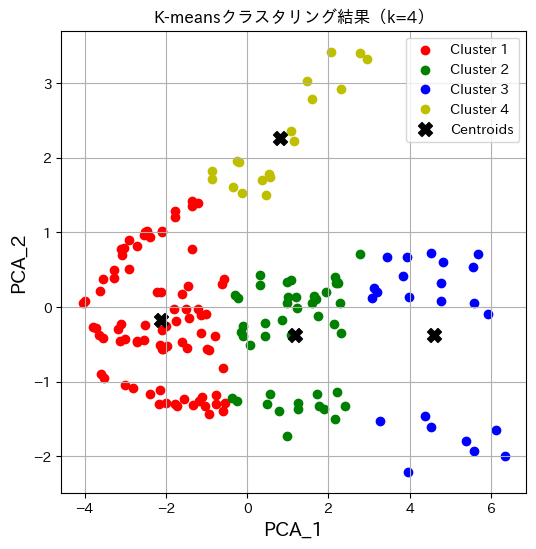

In [37]:
# クラスタリング結果のプロット
fig, ax = plt.subplots(figsize=(6,6))

colors = ['r', 'g', 'b','y']

for i in range(4):
    plt.scatter(X_pca[y_kmeans == i, 0], X_pca[y_kmeans == i, 1], 
                color=colors[i], label=f'Cluster {i+1}')
    
# クラスタの中心をプロット
centroids = kmeans.cluster_centers_
centroids_pca = pca.transform(centroids)

plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], 
            color='black', marker='X', s=100, label='Centroids')

plt.xlabel('PCA_1', fontsize =14)
plt.ylabel('PCA_2', fontsize =14)

plt.legend()
plt.grid()
plt.title('K-meansクラスタリング結果（k=4）')

plt.show()

### ④　教師なしクラスタリングは、本当に4品種を見分けられたのか

k-meansはラベル（茶の品種）を一切見ずに4つのクラスタに分けました。では、このクラスタ分けは、実際の品種とどれくらい一致しているのでしょうか。ここでだけラベルを使って、答え合わせをしてみましょう。

In [38]:
# k-meansのクラスタ番号と、実際の品種ラベルを突き合わせる
comparison_table = pd.crosstab(pd.Series(y_kmeans, name='KMeansクラスタ'), y)
comparison_table

tea,BC,BT,GC,GT
KMeansクラスタ,,,,
0,24,18,20,20
1,0,17,14,14
2,0,7,8,8
3,18,0,0,0


表を見ると、特定の品種（例えばブラックセイロン(BC)）については比較的きれいに1つのクラスタにまとまっている一方、他の品種同士は複数のクラスタにまたがって混ざり合っていることが分かるはずです。これは、**元素組成だけから教師なしで4品種すべてを完全に見分けるのは簡単ではない**ことを示しています。一方で、分類編（`Scikit-learn-5_Classification.ipynb`）ではラベルを使った教師あり学習（決定木・ランダムフォレスト・SVM）によって、高い正解率で4品種を判別できていました。**同じデータでも、ラベルを使うかどうかで、達成できることの水準がまったく違う**、という点が、教師あり学習と教師なし学習の実務上の使い分けを考えるうえで重要な教訓です。

---

# 4. まとめと演習問題

## まとめ

本ノートブックでは、次のことを学びました。

* PCA・t-SNE・UMAPによる次元削減と、それぞれの標準化前後での結果の違い（特にPCAでは、標準化しないと1つの元素（K）だけで結果が決まってしまうことを実際の数値で確認しました）
* 寄与率・累積寄与率によるPCAの情報保持量の確認
* 階層クラスタリング（デンドログラム）とk-means（エルボー法によるクラスタ数の検討）
* PCAで2次元に落としたうえでのk-meansクラスタリング結果の可視化
* 教師なしクラスタリングの結果を、実際のラベルと突き合わせて「どれくらい正解に近いか」を確認する方法、およびその結果が教師あり学習（分類編）ほど明確ではないこと

## 本ノートブックでは扱っていないこと（今後の課題）

1. **シルエット分析など、エルボー法以外のクラスタ数決定手法は扱っていません。**
2. **t-SNE・UMAPの主要パラメータ（`perplexity`・`n_neighbors`など）を変えた比較は行っていません。**
3. **階層クラスタリングの`method`（linkage法）を変えた比較は行っていません。**

## 演習問題

1. `KMeans`の`n_clusters`を4ではなく2や8に変えてPCA平面上にプロットし直し、クラスタの分かれ方がどう変わるか確認してみましょう。
2. t-SNEの`perplexity`を5・30・50と変えて、プロットの見た目がどう変わるか比較してみましょう。
3. UMAPの`n_neighbors`を5・15・50と変えて、同様に比較してみましょう。
4. 階層クラスタリングの`method`を`'ward'`から`'average'`や`'complete'`に変えて、デンドログラムの形がどう変わるか確認してみましょう。